# Comparing RDKit and Mordred Descriptors for ADME Prediction

This notebook benchmarks two molecular descriptor sets — **RDKit descriptors** and **Mordred descriptors** — paired with two different ML models (LightGBM and a feed-forward neural network) on the Biogen public ADME dataset. The pipeline:

1. Load SMILES + assay data and pre-compute three molecular representations (Morgan fingerprints, RDKit descriptors, Mordred descriptors).
2. Use `useful_rdkit_utils`' `WrapperFactory` to bind each descriptor set to each model class.
3. Run grouped (Butina-clustered) cross-validation across all six LOG assays in the dataset.
4. Summarize performance with R² and MAE, then visualize with bar plots and Tukey HSD pairwise-difference plots.

In [30]:
import pandas as pd
import useful_rdkit_utils as uru
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from ffnn import FFNNRegressor
import warnings
from tqdm.auto import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from mordred import Calculator, descriptors
from rdkit import Chem

In [31]:
tqdm.pandas()

## Load the dataset and compute Morgan fingerprints

Pull the Biogen public ADME dataset (3,521 compounds with six assay endpoints, all named `LOG*`) directly from GitHub. For each SMILES we precompute a Morgan count fingerprint via `uru.Smi2Fp` and stash it in a SMILES → fingerprint dictionary so the wrapper classes downstream can do constant-time lookups during cross-validation.

In [32]:
df = pd.read_csv("https://raw.githubusercontent.com/molecularinformatics/Computational-ADME/refs/heads/main/ADME_public_set_3521.csv")
df["fp"] = df.SMILES.progress_apply(uru.Smi2Fp().get_np_counts)
fp_dict = dict(df[["SMILES","fp"]].values)

  0%|          | 0/3521 [00:00<?, ?it/s]

## Compute and preprocess RDKit descriptors

Compute the ~200 physicochemical/topological descriptors that ship with RDKit, then pass them through `uru.DescriptorPreprocessor`, which handles imputation of bad values and scaling. The result is again stored in a SMILES → descriptor-vector dictionary.

In [4]:
df["rdkit_desc"] = df.SMILES.progress_apply(uru.RDKitDescriptors().calc_smiles)
# Scale the descriptors 
rdkit_desc_pre = uru.DescriptorPreprocessor()
df.rdkit_desc = rdkit_desc_pre.fit_transform(np.stack(df.rdkit_desc)).tolist()
rdkit_desc_dict = dict(df[["SMILES","rdkit_desc"]].values)

  0%|          | 0/3521 [00:00<?, ?it/s]

## Compute and preprocess Mordred descriptors

Mordred produces a much larger 2D descriptor set (~1,600 features with `ignore_3D=True`). The Mordred calculator operates on RDKit `Mol` objects, so we materialize a `mol` column first. The same `DescriptorPreprocessor` pattern is applied to drop/repair invalid columns and scale the matrix. This step is the slowest in the notebook (~1–2 minutes).

In [5]:
calc = Calculator(descriptors, ignore_3D=True)
df["mol"] = df.SMILES.progress_apply(Chem.MolFromSmiles)
mordred_desc = calc.pandas(df.mol).values.tolist()
mordred_desc_pre = uru.DescriptorPreprocessor()
df["mordred_desc"] = mordred_desc_pre.fit_transform(np.stack(mordred_desc)).tolist()
mordred_desc_dict = dict(df[["SMILES","mordred_desc"]].values)

  0%|          | 0/3521 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████| 3521/3521 [01:34<00:00, 37.33it/s]


Now we can select the descriptors we want to use in validation below and assign them to the **desc_dict** variable.  This variable is used to instantiate the wrapper classes below

In [10]:
desc_dict = mordred_desc_dict

## Build descriptor + model wrapper classes

`uru.WrapperFactory.create_wrapper_class` dynamically generates a scikit-learn-compatible estimator that pairs a model class with a fixed SMILES → descriptor lookup. The wrapper handles featurization internally, so the cross-validation loop only needs to pass SMILES — not feature matrices — to `.fit` / `.predict`. We build four wrappers spanning the two descriptor sets (RDKit, Mordred) × two model families (LightGBM, FFNN).

In [19]:
LGBMRDKitWrapper = uru.WrapperFactory.create_wrapper_class(
    model_class=LGBMRegressor, 
    descriptor_dict=rdkit_desc_dict,
    class_name="LGBMRDKitWrapper",
    verbose=-1
)

FFNNRDKitWrapper = uru.WrapperFactory.create_wrapper_class(
    model_class=FFNNRegressor, 
    descriptor_dict=rdkit_desc_dict,
    class_name="FFNNRDKitWrapper",
)

LGBMMordredWrapper = uru.WrapperFactory.create_wrapper_class(
    model_class=LGBMRegressor, 
    descriptor_dict=mordred_desc_dict,
    class_name="LGBMMordredWrapper",
    verbose=-1
)

FFNNMordredWrapper = uru.WrapperFactory.create_wrapper_class(
    model_class=FFNNRegressor, 
    descriptor_dict=mordred_desc_dict,
    class_name="FFNNMordredWrapper",
)

## Configure the benchmark

`method_list` holds the four (name, wrapper) pairs to compare. `group_list` defines the splitting strategy — here, Butina clustering on Morgan fingerprints (`uru.get_butina_clusters`), which assigns structurally similar molecules to the same fold so the held-out set tests genuine generalization rather than memorization of close analogs.

In [21]:
method_list = [("LGBM_RDKit",LGBMRDKitWrapper),("FFNN_RDKit",FFNNRDKitWrapper),("LGBM_Mordred",LGBMMordredWrapper),("FFNN_Mordred",FFNNMordredWrapper)]
method_name_list = [x[0] for x in method_list]        
group_list = [("butina",uru.get_butina_clusters)] 

# Remove an annoying LGBM warning
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.validation")

## Cross-validate every model on every assay

For each of the six `LOG*` assay columns:

1. Drop rows with missing labels for that assay.
2. Recompute fingerprints (needed by the Butina grouper).
3. Call `uru.cross_validate`, which runs each `(method, group)` combination through grouped k-fold CV and returns per-fold predictions.

Results from every assay are appended to `df_list`. This is the most expensive step in the notebook (tens of minutes of wall time).

In [22]:
%%time
assay_cols = [x for x in df.columns if x.startswith("LOG")]
df_list = []
with tqdm(assay_cols) as pbar:
    for col in pbar:
        tmp_df = df.dropna(subset=col)
        tmp_df["fp"] = tmp_df.SMILES.apply(uru.Smi2Fp().get_np_counts)   
        result_df = uru.cross_validate(tmp_df,
                                       model_list=method_list,
                                       y_col=col,
                                       group_list=group_list)
        result_df['assay'] = col
        df_list.append(result_df)

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

butina:   0%|          | 0/5 [00:00<?, ?it/s]

butina:   0%|          | 0/5 [00:00<?, ?it/s]

butina:   0%|          | 0/5 [00:00<?, ?it/s]

...

butina:   0%|          | 0/5 [00:00<?, ?it/s]

butina:   0%|          | 0/5 [00:00<?, ?it/s]

butina:   0%|          | 0/5 [00:00<?, ?it/s]

butina:   0%|          | 0/5 [00:00<?, ?it/s]

CPU times: user 32min 1s, sys: 5.17 s, total: 32min 6s
Wall time: 8min 33s


## Summarize R² and MAE per assay × method

`uru.get_performance_stats` walks the per-fold predictions and returns one R² DataFrame and one MAE DataFrame per assay, with the method name attached. The lists are concatenated into tidy long-form frames (`r2_combo_df`, `mae_combo_df`) ready for plotting.

In [23]:
r2_df_list = []
mae_df_list = []
for assay,res_df in zip(assay_cols,df_list):
    r2_df, mae_df = uru.get_performance_stats(res_df,
          method_list=method_name_list,y_col=assay)
    r2_df["assay"] = assay
    mae_df["assay"] = assay
    r2_df_list.append(r2_df)
    mae_df_list.append(mae_df)

In [24]:
r2_combo_df = pd.concat(r2_df_list).reset_index(drop=True)
mae_combo_df = pd.concat(mae_df_list).reset_index(drop=True)

## Visualize results

`uru.plot_r2_mae` produces a side-by-side bar plot of R² and MAE, faceted by assay, with one bar per method — a quick visual ranking of the four descriptor/model combinations on each endpoint.

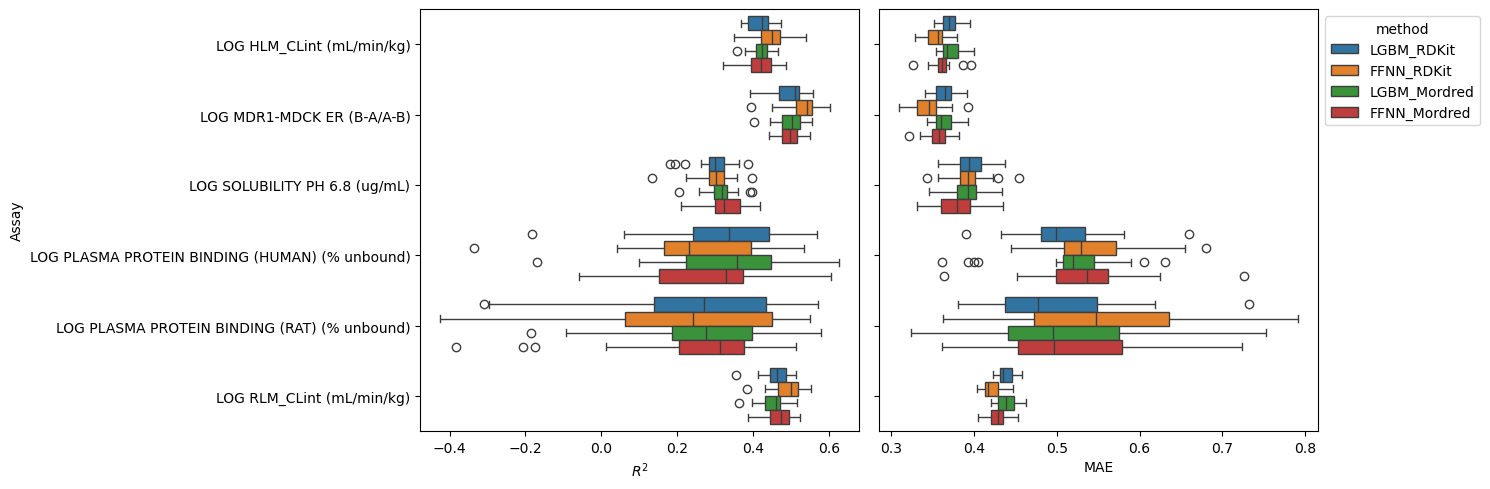

In [25]:
uru.plot_r2_mae(r2_combo_df, mae_combo_df)

## Test whether the differences are statistically meaningful

Bar heights alone can be misleading — Butina folds vary in size and difficulty. `uru.plot_tukey` runs Tukey's HSD post-hoc test across methods for each assay and visualizes the pairwise mean differences with confidence intervals. Intervals that don't cross zero indicate a statistically significant difference between two methods on that assay. We run it on both R² (next cell) and MAE (cell after).

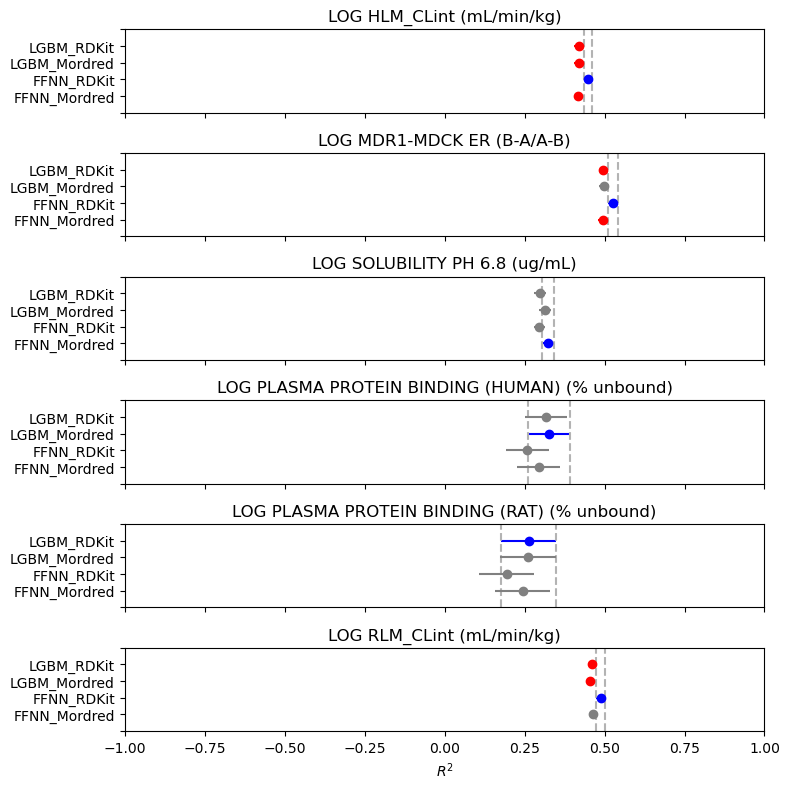

In [28]:
uru.plot_tukey(r2_df_list, assay_cols, "r2",figheight=8)

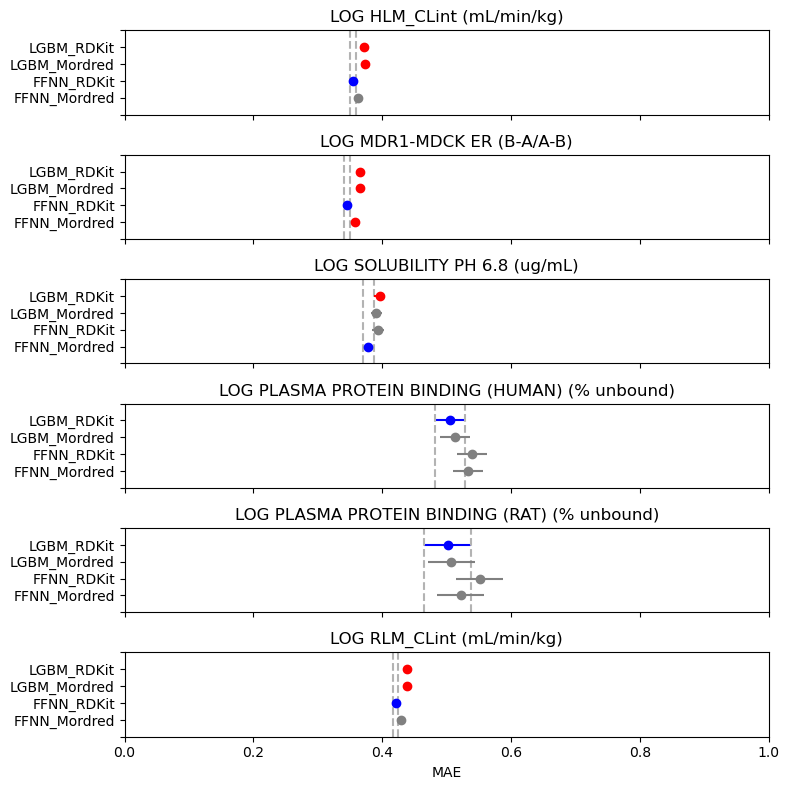

In [29]:
uru.plot_tukey(mae_df_list, assay_cols, "mae",figheight=8)